In [11]:
import pandas as pd
file_path = '/content/aerofit_treadmill.txt'
df = pd.read_csv(file_path)
print(df.head())

  Product  Age  Gender  Education MaritalStatus  Usage  Fitness  Income  Miles
0   KP281   18    Male         14        Single      3        4   29562    112
1   KP281   19    Male         15        Single      2        3   31836     75
2   KP281   19  Female         14     Partnered      4        3   30699     66
3   KP281   19    Male         12        Single      3        3   32973     85
4   KP281   20    Male         13     Partnered      4        2   35247     47


In [12]:
print('DataFrame:')
df.info()

DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [13]:
print('\nDescriptive Statistics:')
df.describe()


Descriptive Statistics:


,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


###Descriptive Statistics:

For the numerical columns, we can observe:

Age: Ranges from 18 to 50 years, with a mean of approximately 28.8 years.

Education: Ranges from 12 to 21 years of education, with a mean of around 15.6 years.

Usage: Indicates how often the treadmill is used, ranging from 2 to 7 times per week, with a mean of 3.45.

Fitness: A self-rated fitness level from 1 to 5, with a mean of 3.31.

Income: Ranges from  29,562 to  29,562 dollars to 104,581 dollars, with a mean income of approximately 53,719 dollars.

Miles: The average number of miles walked/run per week, ranging from 21 to 360 miles, with a mean of about 103 miles.

In [14]:
print('\nMissing Values:')
print(df.isnull().sum())


Missing Values:
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64


**Missing Values:**

There are no missing values across any of the columns in the dataset.
Overall, the dataset is clean

In [28]:
# Non-Graphical Analysis: Value counts and unique attributes
print('Non-Graphical Analysis of Categorical Attributes:\n')

categorical_cols = ['Product', 'Gender', 'MaritalStatus'] # Define categorical_cols

for col in categorical_cols:
    print(f'Attribute: {col}')
    print(f'Unique Values: {df[col].unique().tolist()}')
    print(f'Number of Unique Values: {df[col].nunique()}')
    print('Value Counts:')
    print(df[col].value_counts())
    print('-' * 30)

Non-Graphical Analysis of Categorical Attributes:

Attribute: Product
Unique Values: ['KP281', 'KP481', 'KP781']
Number of Unique Values: 3
Value Counts:
Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64
------------------------------
Attribute: Gender
Unique Values: ['Male', 'Female']
Number of Unique Values: 2
Value Counts:
Gender
Male      104
Female     76
Name: count, dtype: int64
------------------------------
Attribute: MaritalStatus
Unique Values: ['Single', 'Partnered']
Number of Unique Values: 2
Value Counts:
MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64
------------------------------


### Detecting Outliers

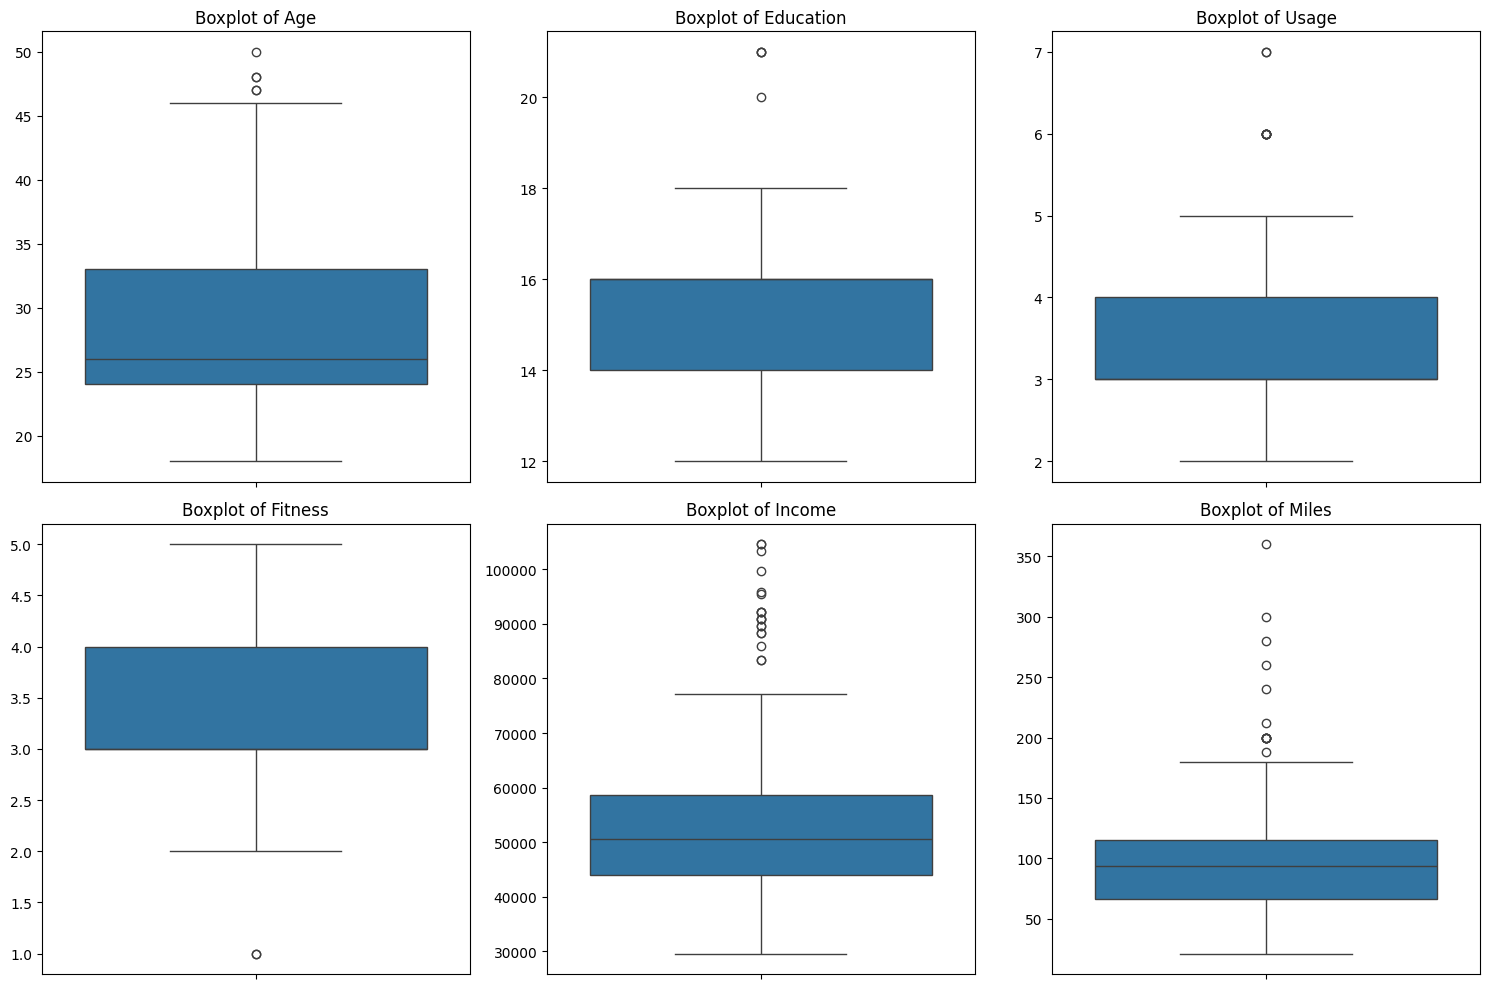

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for boxplots
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set up the matplotlib figure and axes for subplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Interpreting Mean vs. Median for Outlier Detection

Age: Shows a few potential outliers on the higher side, indicating some older customers.

Education: Appears to have some outliers at both the lower and higher ends, suggesting a wider range of educational backgrounds than the interquartile range.

Usage: Also has several outliers on the higher side, implying some customers use the treadmill significantly more than average.

Fitness: Shows a few lower outliers, suggesting some customers self-rate their fitness lower than the majority.

Income: Has numerous outliers on the higher side, indicating a segment of customers with considerably higher incomes.

Miles: Presents several high outliers, meaning some users run/walk significantly more miles per week.

Mean > Median, the distribution is right-skewed, often due to high-value outliers pulling the mean up. Conversely, if Mean < Median, it's left-skewed, potentially due to low-value outliers.

By comparing the mean and median from the df.describe() output, especially for columns like Income and Miles where we saw many high outliers in the boxplots, you'll likely observe that the mean is notably higher than the median, confirming the presence of these upward-pulling outliers.

In [30]:
# Convert categorical attributes to 'category' type
categorical_cols = ['Product', 'Gender', 'MaritalStatus']
for col in categorical_cols:
    df[col] = df[col].astype('category')

print('Updated Data Types:')
print(df.dtypes)

Updated Data Types:
Product          category
Age                 int64
Gender           category
Education           int64
MaritalStatus    category
Usage               int64
Fitness             int64
Income              int64
Miles               int64
dtype: object


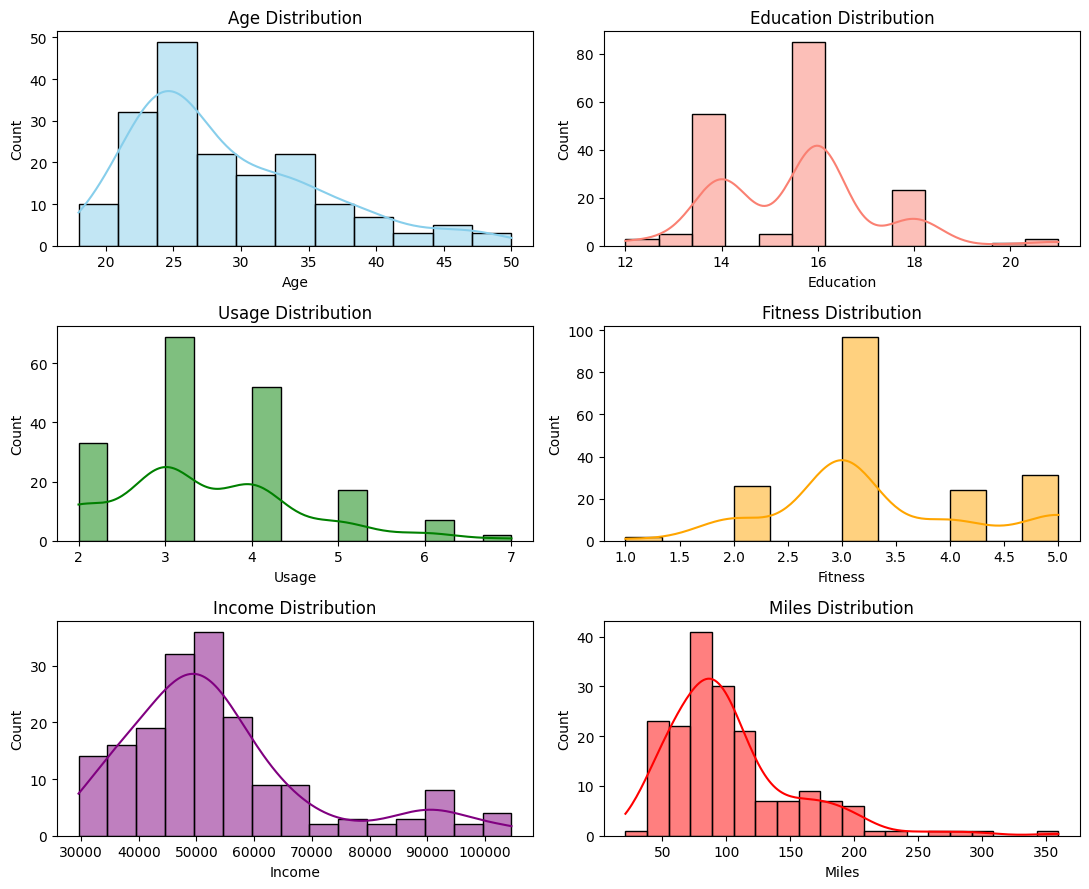

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-loading df for this cell to ensure it's defined
file_path = '/content/aerofit_treadmill.txt'
df = pd.read_csv(file_path)

# Univariate Analysis - Continuous Variables (Histograms/Distplots)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(11,9))

# Age distribution
sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')

# Education distribution
sns.histplot(df['Education'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Education Distribution')

# Usage distribution
sns.histplot(df['Usage'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Usage Distribution')

# Fitness distribution
sns.histplot(df['Fitness'], kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Fitness Distribution')

# Income distribution
sns.histplot(df['Income'], kde=True, ax=axes[2, 0], color='purple')
axes[2, 0].set_title('Income Distribution')

# Miles distribution
sns.histplot(df['Miles'], kde=True, ax=axes[2, 1], color='red')
axes[2, 1].set_title('Miles Distribution')

plt.tight_layout()
plt.show()

### Analyzing Feature Relationships with Product Purchased

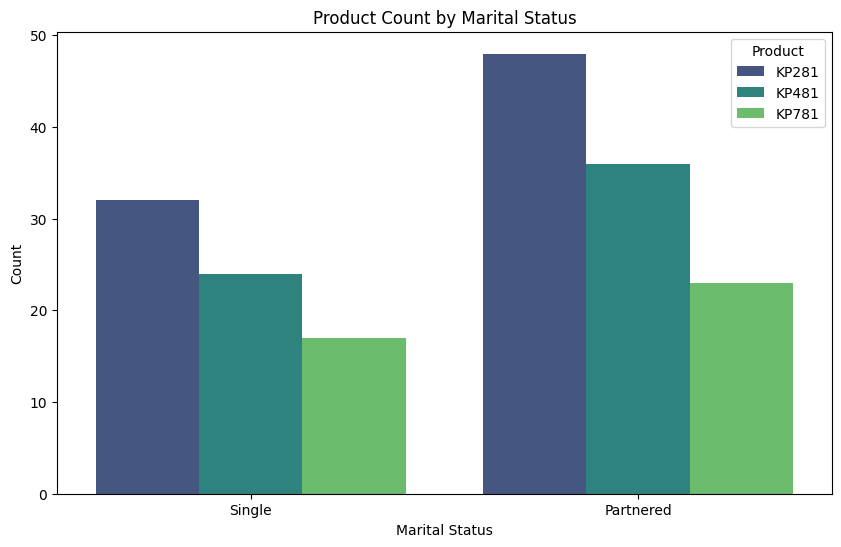

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# MaritalStatus vs Product
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='MaritalStatus', hue='Product', palette='viridis')
plt.title('Product Count by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

###Marital Status vs. Product
From the countplot, we can see how different marital statuses correlate with product purchases:

KP281: This product is popular among both Single and Partnered individuals, with a slightly higher count for Partnered users.

KP481: Also shows significant uptake from both Single and Partnered groups, with a similar distribution to KP281.

KP781: This product appears to be purchased predominantly by Partnered individuals.

**Overall the Partnered individuals are the major customers here.**

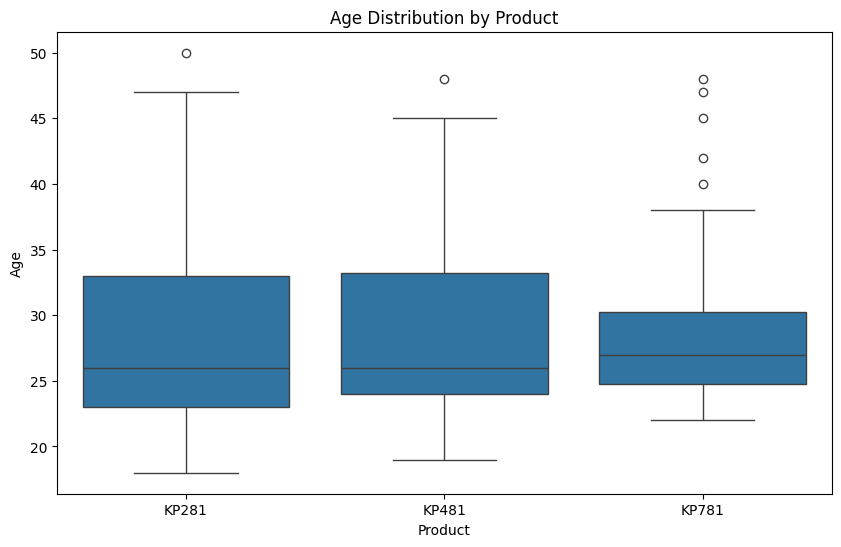

In [33]:
# Age vs Product (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Product', y='Age')
plt.title('Age Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Age')
plt.show()

###Age Distribution by Product
Looking at the boxplot for Age:

KP281 & KP481: Both products show a relatively similar age distribution, with most users being in their mid-to-late 20s. There are some older outliers for KP281.

KP781: Users of the KP781 tend to be slightly older on average, with a higher median age compared to the other two products, and also a wider age range for its users.

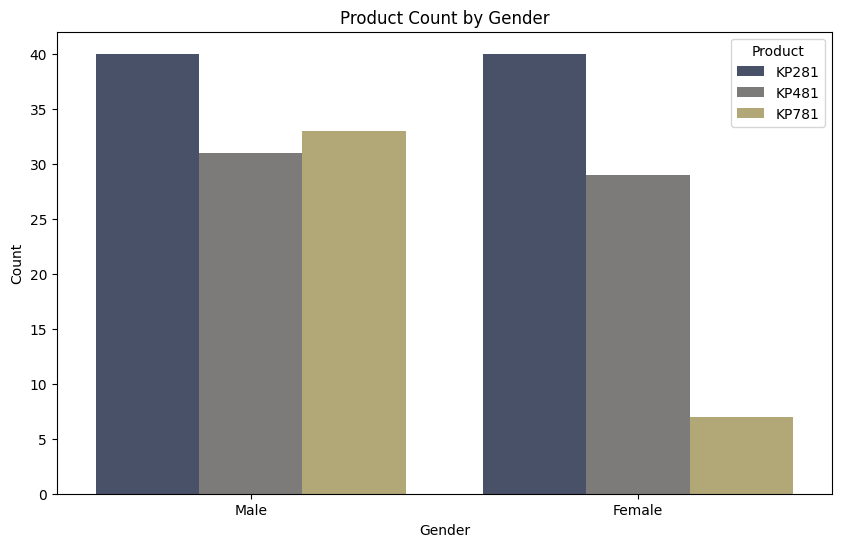

In [34]:
# Gender vs Product
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gender', hue='Product', palette='cividis')
plt.title('Product Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

###Gender vs. Product
From the countplot for Gender:

KP281 & KP481: These products appear to be more evenly distributed between males and females, though KP481 seems to have a slightly higher number of male users.

KP781: This product is overwhelmingly purchased by males, with a very small number of female buyers.

with gender, income also plays a key role in the purchasing power of the customers

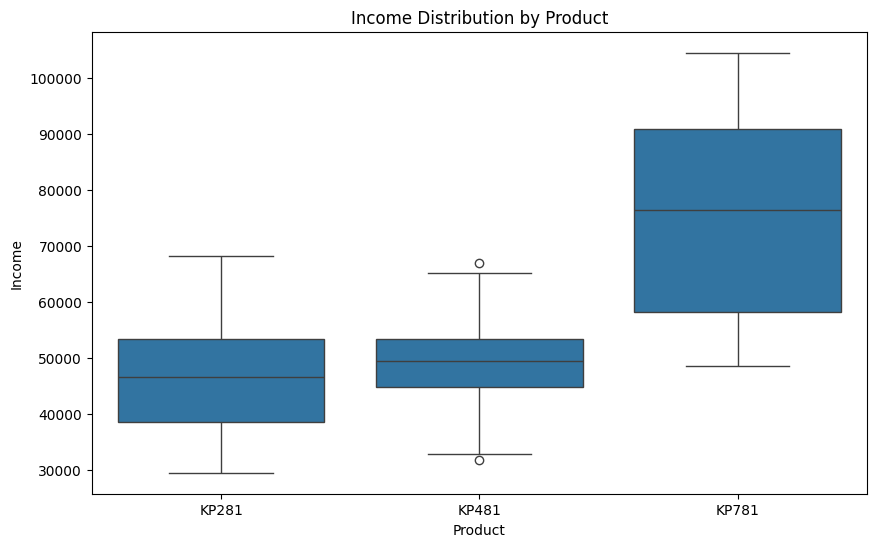

In [17]:
# Income vs Product (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Product', y='Income')
plt.title('Income Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Income')
plt.show()

###Overall Product Relationships:
**Product KP781 (Premium Model):**

Users: Tend to be older, more educated, with significantly higher incomes.
Gender & Marital Status: Predominantly purchased by males and often by partnered individuals.
Target Audience: This model clearly targets a more affluent, highly fitness-motivated, and serious user base.

**Product KP481 (Mid-Range Model):**

Users: Age and education are similar to KP281 users, but with a slightly higher income ceiling.
Gender & Marital Status: Appeals to both genders and both single/partnered individuals
Target Audience: Caters to a broad audience looking for a balance of features and value, likely moderate fitness enthusiasts.

**Product KP281 (Entry-Level Model):**

Users: Generally younger, with average education levels and lower incomes compared to the other models.
Gender & Marital Status: Popular among both single and partnered individuals, and fairly evenly distributed between genders.
Target Audience: Likely targets first-time buyers or casual users with budget considerations and moderate fitness goals.

In [18]:
# Calculate the marginal probability of each product
product_percentages = df['Product'].value_counts(normalize=True) * 100

# Convert to a DataFrame for better display
product_percentages_df = product_percentages.reset_index()
product_percentages_df.columns = ['Product', 'Percentage of Customers']

print('Marginal Probability of Product Purchases:')
print(product_percentages_df.to_string(index=False))


Marginal Probability of Product Purchases:
Product  Percentage of Customers
  KP281                44.444444
  KP481                33.333333
  KP781                22.222222


###Correlation Analysis using Heatmap

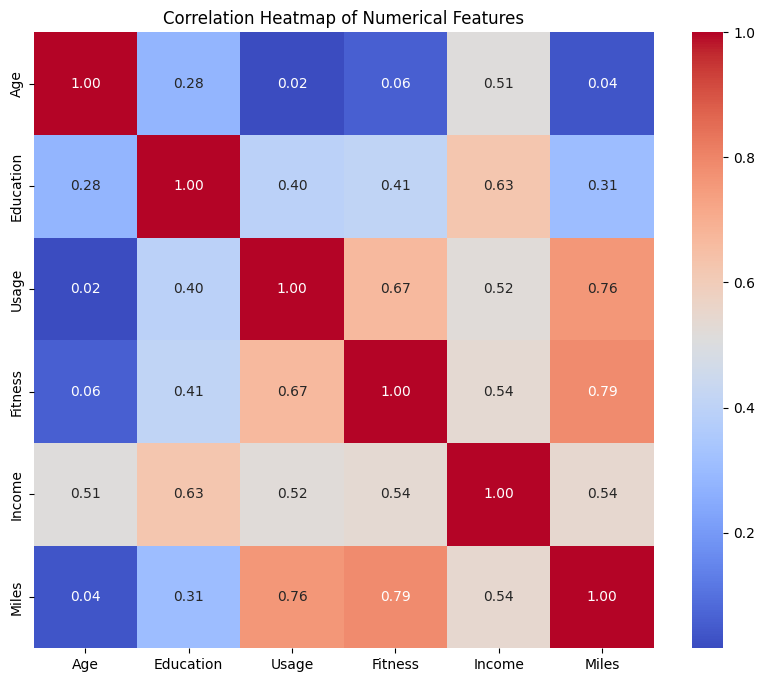

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

###Correlation Heatmap Interpretation:

**Fitness and Miles (0.79):** There's a very strong positive correlation between how fit a person rates themselves and the number of miles they plan to run/walk per week.

**Usage and Miles (0.76):** Similarly, the planned usage (how many times per week) is highly correlated with the miles covered. More frequent use generally means more miles.

**Usage and Fitness (0.67):** People who use the treadmill more frequently also tend to have higher self-rated fitness levels.

**Income with Usage (0.52), Fitness (0.54), Miles (0.54):** Higher income individuals tend to use the treadmill more, are fitter, and cover more miles. This suggests that more affluent customers might be investing in health and fitness.

**Education with Usage (0.40), Fitness (0.41), Miles (0.31):** Higher education levels show a moderate positive correlation with treadmill usage, fitness, and miles, implying an awareness or means to prioritize health.

**Age with Usage (0.02) and Miles (0.04):** Age itself shows very little linear correlation with how often or how far someone uses the treadmill. This means that while older users might exist, age alone doesn't predict usage intensity.

### Probability of a Male Customer Buying types of Treadmills

In [20]:

male_customers = df[df['Gender'] == 'Male']
kp781_male_count = male_customers[male_customers['Product'] == 'KP781'].shape[0]
total_male_count = male_customers.shape[0]
probability = (kp781_male_count / total_male_count) * 100

print(f"Number of male customers who bought KP781: {kp781_male_count}")
print(f"Total number of male customers: {total_male_count}")
print(f"The probability of a male customer buying a KP781 treadmill is: {probability:.2f}%")


Number of male customers who bought KP781: 33
Total number of male customers: 104
The probability of a male customer buying a KP781 treadmill is: 31.73%


In [21]:
male_customers = df[df['Gender'] == 'Male']
kp481_male_count = male_customers[male_customers['Product'] == 'KP481'].shape[0]
total_male_count = male_customers.shape[0]
probability = (kp481_male_count / total_male_count) * 100

print(f"Number of male customers who bought KP481: {kp481_male_count}")
print(f"Total number of male customers: {total_male_count}")
print(f"The probability of a male customer buying a KP481 treadmill is: {probability:.2f}%")

Number of male customers who bought KP481: 31
Total number of male customers: 104
The probability of a male customer buying a KP481 treadmill is: 29.81%


In [22]:
male_customers = df[df['Gender'] == 'Male']
kp281_male_count = male_customers[male_customers['Product'] == 'KP281'].shape[0]
total_male_count = male_customers.shape[0]
probability = (kp281_male_count / total_male_count) * 100

print(f"Number of male customers who bought KP281: {kp281_male_count}")
print(f"Total number of male customers: {total_male_count}")
print(f"The probability of a male customer buying a KP281 treadmill is: {probability:.2f}%")

Number of male customers who bought KP281: 40
Total number of male customers: 104
The probability of a male customer buying a KP281 treadmill is: 38.46%


### Probability of a Female Customer Buying types of Treadmills

In [23]:
female_customers = df[df['Gender'] == 'Female']
kp781_female_count = female_customers[female_customers['Product'] == 'KP781'].shape[0]
total_female_count = female_customers.shape[0]
probability_female_kp781 = (kp781_female_count / total_female_count) * 100

print(f"Number of female customers who bought KP781: {kp781_female_count}")
print(f"Total number of female customers: {total_female_count}")
print(f"The probability of a female customer buying a KP781 treadmill is: {probability_female_kp781:.2f}%")

Number of female customers who bought KP781: 7
Total number of female customers: 76
The probability of a female customer buying a KP781 treadmill is: 9.21%


In [24]:
female_customers = df[df['Gender'] == 'Female']
kp481_female_count = female_customers[female_customers['Product'] == 'KP481'].shape[0]
total_female_count = female_customers.shape[0]
probability = (kp481_female_count / total_female_count) * 100

print(f"Number of female customers who bought KP481: {kp481_female_count}")
print(f"Total number of female customers: {total_female_count}")
print(f"The probability of a female customer buying a KP481 treadmill is: {probability:.2f}%")

Number of female customers who bought KP481: 29
Total number of female customers: 76
The probability of a female customer buying a KP481 treadmill is: 38.16%


In [25]:
female_customers = df[df['Gender'] == 'Female']
kp281_female_count = female_customers[female_customers['Product'] == 'KP281'].shape[0]
total_female_count = female_customers.shape[0]
probability = (kp281_female_count / total_female_count) * 100

print(f"Number of female customers who bought KP281: {kp281_female_count}")
print(f"Total number of female customers: {total_female_count}")
print(f"The probability of a female customer buying a KP281 treadmill is: {probability:.2f}%")

Number of female customers who bought KP281: 40
Total number of female customers: 76
The probability of a female customer buying a KP281 treadmill is: 52.63%


###Comparing the distributions reveals distinct purchasing patterns between genders:

**KP281 (Entry-Level):** This is the most popular model for both genders, but significantly more so for females (52.63%) than males (38.46%).

**KP481 (Mid-Range):** This model sees similar interest from both, with 38.16% of females and 29.81% of males choosing it.

**KP781 (Premium):** There is a stark contrast here. It is a major choice for males (31.73%), but only a tiny fraction of females (9.21%) purchase this model.

**Conclusion:** Female customers predominantly gravitate toward the entry and mid-range models (over 90% combined), while male customers are much more evenly spread across all three levels, showing a much higher inclination toward the premium KP781 model.

### Customer Profiling

**1. KP281 (Entry-Level Model)**
*   **Target Audience:** Budget-conscious or casual fitness users.
*   **Demographics:** Generally younger users with lower to moderate income levels and average education.
*   **Usage:** Moderate usage and fitness self-ratings.

**2. KP481 (Mid-Range Model)**
*   **Target Audience:** Moderate fitness enthusiasts looking for a balance between cost and features.
*   **Demographics:** Similar age range to KP281 but with slightly higher income ceilings.
*   **Usage:** Consistent weekly usage and miles.

**3. KP781 (Premium Model)**
*   **Target Audience:** Serious athletes and high-income individuals.
*   **Demographics:** Highly educated, significantly higher income, and slightly older on average.
*   **Usage:** Heavy users (highest frequency and miles) with the highest self-rated fitness levels.

In [26]:
# Conditional Probability: P(Product | Gender)
print('Conditional Probability of Product given Gender:')
gender_conditional = pd.crosstab(df['Gender'], df['Product'], normalize='index')
display(gender_conditional)

# Conditional Probability: P(Product | MaritalStatus)
print('\nConditional Probability of Product given Marital Status:')
marital_conditional = pd.crosstab(df['MaritalStatus'], df['Product'], normalize='index')
display(marital_conditional)

Conditional Probability of Product given Gender:


Product,KP281,KP481,KP781
Gender,,,
Female,0.526316,0.381579,0.092105
Male,0.384615,0.298077,0.317308



Conditional Probability of Product given Marital Status:


Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,0.448598,0.336449,0.214953
Single,0.438356,0.328767,0.232877


**Conditional Probabilities (Gender):** As we noted, female customers have a high probability of choosing the KP281 (52.6%), whereas male customers have a much higher conditional probability of purchasing the premium KP781 (31.7%) compared to females (9.2%).

**Conditional Probabilities (Marital Status):** Interestingly, marital status has a very small impact on product choice. Both 'Partnered' and 'Single' customers show almost identical purchasing probabilities across all three models, suggesting that marital status is not a strong differentiator for product targeting in this dataset.

### Recommendations and Actionable Insights

**1. Target High-Income Males for KP781:**

*   **Insight:** The KP781 is predominantly purchased by males with high income and high fitness levels.
*   **Action:** Launch targeted digital ad campaigns on platforms frequented by high-earning professionals. Highlight features like advanced tracking and durability that appeal to 'serious' runners.

**2. Expand Female Market Share for KP481:**

*   **Insight:** While females prefer the KP281, a significant portion also buys the KP481. However, very few buy the KP781.
*   **Action:** Market the KP481 as a 'step-up' model for female users who want more features than the entry-level model but don't need the extreme specifications of the KP781.

**3. Focus on Partnered Individuals:**

*   **Insight:** A larger volume of customers are 'Partnered' across all models.
*   **Action:** Create 'Family' or 'Couple' promotional bundles. Since marital status doesn't significantly change the *type* of product bought, focus on volume-based discounts for households.

**4. Entry-Level Engagement for Younger Demographics:**

*   **Insight:** Younger users (early 20s) with lower incomes are the primary demographic for the KP281.
*   **Action:** Offer flexible EMI schemes or student discounts to make the KP281 even more accessible to this budget-conscious group.

**5. Leverage Fitness-Usage Correlation:**

*   **Insight:** There is a strong correlation between self-rated fitness and miles/usage.
*   **Action:** Include a fitness app subscription or personal training session with the KP781 to reinforce the 'Premium Fitness' lifestyle that these customers value.